**📝 Instrucciones**

## Airbnb en Nueva York

Una empresa ha recolectado la información del alquiler de viviendas en Nueva York a través de la aplicación Airbnb durante el año 2019. Este conjunto de datos se utilizó para entrenar modelos de Machine Learning durante ese año, en una competición en abierto.

Ahora lo utilizaremos para llevar a cabo un estudio acerca de las variables que componen el dataset a fin de comprenderlo y obtener conclusiones sobre él.

**Paso 1**: Carga del conjunto de datos
Puedes descargar el conjunto de datos directamente desde Kaggle.com o en el siguiente enlace: https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv. Almacena los datos en crudo en la carpeta ./data/raw.

**Paso 2**: Realiza un EDA completo
Este paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en la lección.

**Paso 3**: Guarda el conjunto de datos procesado
Después del EDA puedes guardar los datos en la carpeta ./data/processed. Asegúrate de agregar la carpeta de los datos en el .gitignore. Los datos al igual que los modelos no se deben subir a git.

In [1]:
import pandas as pd

df = pd.read_csv('/workspaces/ekbalam11-machine-learning/data/raw/AB_NYC_2019.csv') 

In [2]:
f"tuple of rows and columns in df: {df.shape}"

'tuple of rows and columns in df: (48895, 16)'

In [3]:
#Summary of the df:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [4]:
# df['number_of_reviews'].value_counts(ascending=False)
# df.groupby(["neighbourhood", ""]).agg()
df.groupby('neighbourhood_group').agg({'price':['count','sum','mean','std'], 'number_of_reviews':['sum','mean','std']})

price                                  number_of_reviews  \
                     count      sum        mean         std               sum   
neighbourhood_group                                                             
Bronx                 1091    95459   87.496792  106.709349             28371   
Brooklyn             20104  2500600  124.383207  186.873538            486574   
Manhattan            21661  4264527  196.875814  291.383183            454569   
Queens                5666   563867   99.517649  167.102155            156950   
Staten Island          373    42825  114.812332  277.620403             11541   

                                           
                          mean        std  
neighbourhood_group                        
Bronx                26.004583  42.214774  
Brooklyn             24.202845  44.344868  
Manhattan            20.985596  42.572277  
Queens               27.700318  51.955853  
Staten Island        30.941019  44.830766

In [5]:
filtered_df = df[['price','room_type','number_of_reviews','neighbourhood_group','minimum_nights']]
filtered_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   price                48895 non-null  int64
 1   room_type            48895 non-null  str  
 2   number_of_reviews    48895 non-null  int64
 3   neighbourhood_group  48895 non-null  str  
 4   minimum_nights       48895 non-null  int64
dtypes: int64(3), str(2)
memory usage: 1.9 MB


In [6]:
#show total Nan
filtered_df.isna().sum().sum()

np.int64(0)

## FACTORIZACIÓN

In [7]:
filtered_df.room_type

0           Private room
1        Entire home/apt
2           Private room
3        Entire home/apt
4        Entire home/apt
              ...       
48890       Private room
48891       Private room
48892    Entire home/apt
48893        Shared room
48894       Private room
Name: room_type, Length: 48895, dtype: str

In [8]:
pd.factorize(filtered_df["room_type"])[0]
pd.factorize(filtered_df["neighbourhood_group"])[0]

filtered_df["room_type_factor"] = pd.factorize(filtered_df["room_type"])[0]
filtered_df["neighbourhood_group_factor"] = pd.factorize(filtered_df["neighbourhood_group"])[0]


filtered_df[["room_type","room_type_factor","neighbourhood_group_factor"]]

,room_type,room_type_factor,neighbourhood_group_factor
0,Private room,0,0
1,Entire home/apt,1,1
2,Private room,0,1
3,Entire home/apt,1,0
4,Entire home/apt,1,1
...,...,...,...
48890,Private room,0,0
48891,Private room,0,0
48892,Entire home/apt,1,1
48893,Shared room,2,1


In [9]:
filtered_df["neighbourhood_group_factor"].unique()

array([0, 1, 2, 3, 4])

In [10]:
filtered_df["room_type_factor"].unique()

array([0, 1, 2])

In [11]:
filtered_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   price                       48895 non-null  int64
 1   room_type                   48895 non-null  str  
 2   number_of_reviews           48895 non-null  int64
 3   neighbourhood_group         48895 non-null  str  
 4   minimum_nights              48895 non-null  int64
 5   room_type_factor            48895 non-null  int64
 6   neighbourhood_group_factor  48895 non-null  int64
dtypes: int64(5), str(2)
memory usage: 2.6 MB


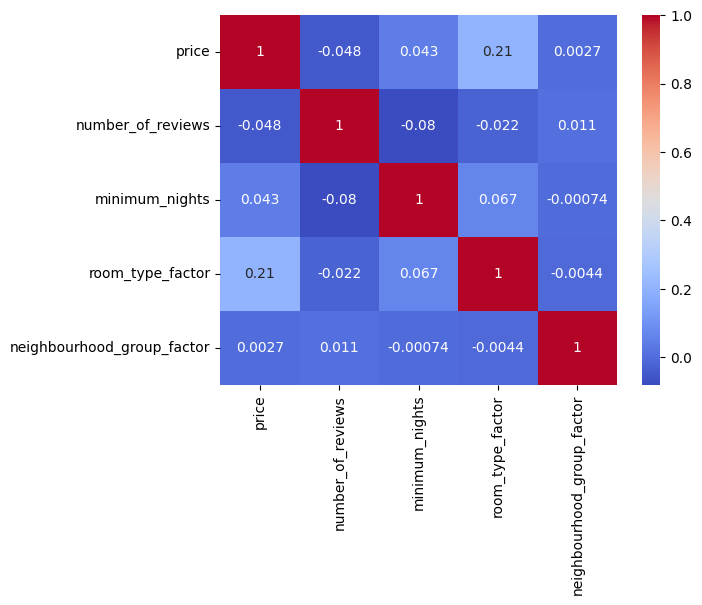

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = filtered_df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

hay sesgo a la derecha (muchos precios bajos y pocos muy altos)

<Axes: xlabel='room_type', ylabel='price'>

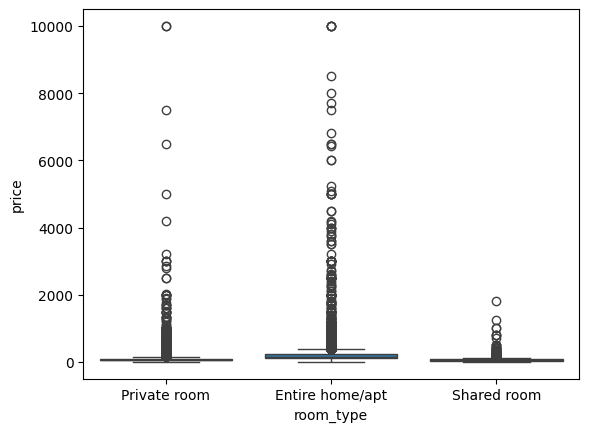

In [9]:
sns.boxplot(x="room_type", y="price", data=df)

neighbourhood_group
Bronx             87.496792
Brooklyn         124.383207
Manhattan        196.875814
Queens            99.517649
Staten Island    114.812332
Name: price, dtype: float64

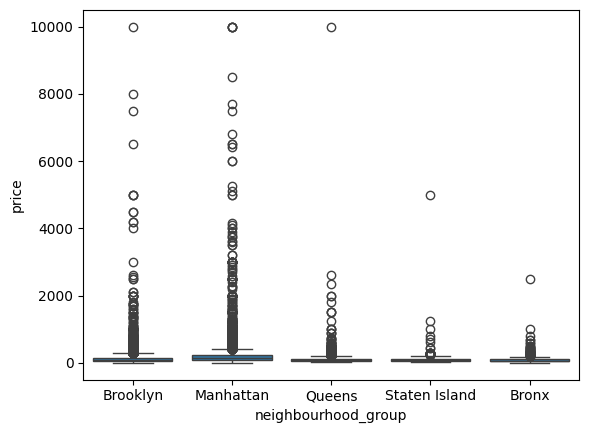

In [24]:
sns.boxplot(x="neighbourhood_group", y="price", data=filtered_df)
filtered_df.groupby("neighbourhood_group")["price"].mean()

<Axes: xlabel='number_of_reviews', ylabel='price'>

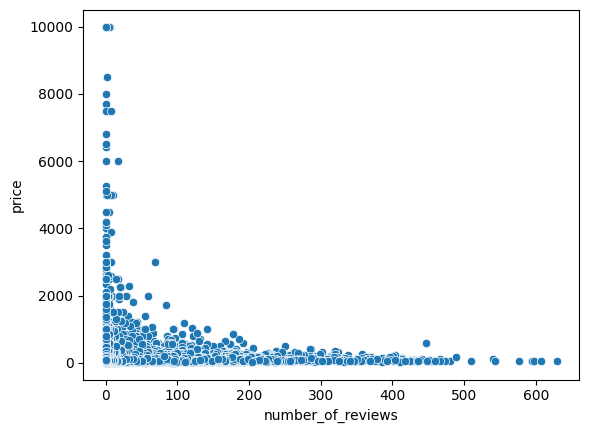

In [25]:
sns.scatterplot(x="number_of_reviews", y="price", data=filtered_df)

room_type
Entire home/apt    1.306578
Private room       1.445209
Shared room        1.471726
Name: reviews_per_month, dtype: float64

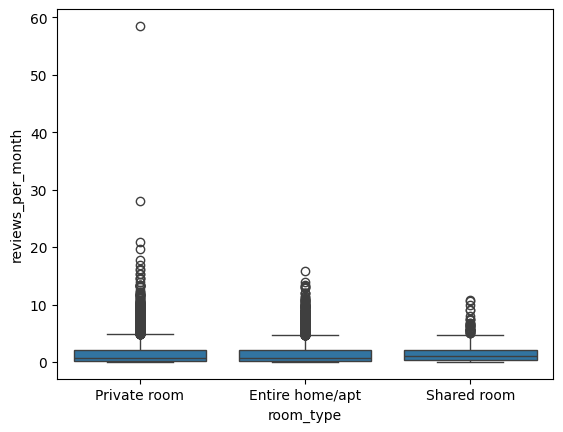

In [27]:
sns.boxplot(x="room_type", y="reviews_per_month", data=df)
df.groupby("room_type")["reviews_per_month"].mean()

<Axes: xlabel='minimum_nights', ylabel='number_of_reviews'>

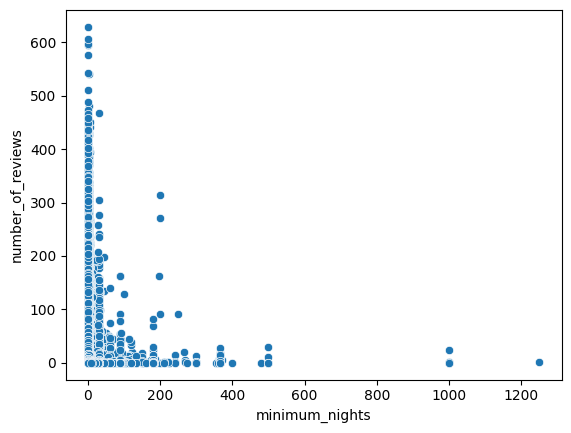

In [28]:
sns.scatterplot(x="minimum_nights", y="number_of_reviews", data=df)

In [14]:
df.groupby("neighbourhood_group")["price"].median().sort_values()

neighbourhood_group
Bronx             65.0
Queens            75.0
Staten Island     75.0
Brooklyn          90.0
Manhattan        150.0
Name: price, dtype: float64

In [35]:
filtered_df.groupby("room_type")["price"].mean()

room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64

In [38]:
price_by_neighbourhood = (
    filtered_df.groupby("neighbourhood_group")["price"]
    .median()
    .sort_values(ascending=False)
)

print(price_by_neighbourhood)

neighbourhood_group
Manhattan        150.0
Brooklyn          90.0
Queens            75.0
Staten Island     75.0
Bronx             65.0
Name: price, dtype: float64


In [40]:
clean_df = filtered_df.dropna()
df_model = pd.get_dummies(clean_df, columns=["room_type", "neighbourhood_group"], drop_first=True)
df_model

,price,number_of_reviews,minimum_nights,room_type_factor,neighbourhood_group_factor,room_type_Private room,room_type_Shared room,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,149,9,1,0,0,True,False,True,False,False,False
1,225,45,1,1,1,False,False,False,True,False,False
2,150,0,3,0,1,True,False,False,True,False,False
3,89,270,1,1,0,False,False,True,False,False,False
4,80,9,10,1,1,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
48890,70,0,2,0,0,True,False,True,False,False,False
48891,40,0,4,0,0,True,False,True,False,False,False
48892,115,0,10,1,1,False,False,False,True,False,False
48893,55,0,1,2,1,False,True,False,True,False,False


In [20]:
X = df_model.drop("price", axis=1)
y = df_model["price"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
from sklearn.metrics import r2_score

pred = model.predict(X_test)

print(r2_score(y_test, pred))

0.14837379285512586
